# Olist E-Commerce Sales Analytics

## Project Overview

This notebook performs exploratory data analysis on the Brazilian E-Commerce Public Dataset by Olist.

The analysis focuses on sales performance, customer behavior, product and category performance, geographic distribution, payment behavior, delivery performance, and customer satisfaction.

The project combines Python-based exploratory analysis with SQL business analysis and an interactive Power BI dashboard.

## Business Objectives

The main objectives of this analysis are:

- Understand overall sales and order performance
- Analyze monthly and yearly sales trends
- Identify top-performing product categories and products
- Analyze customer distribution across Brazilian states
- Understand payment method usage
- Measure delivery performance
- Identify late deliveries
- Analyze customer review scores
- Identify relationships between delivery performance and customer satisfaction

## Technologies

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- MySQL
- SQL
- Power BI
- DAX

## Dataset

The project uses the Brazilian E-Commerce Public Dataset by Olist.

The dataset contains multiple relational tables covering:

- Orders
- Customers
- Order items
- Payments
- Reviews
- Products
- Sellers
- Geolocation
- Product category translation

## Analysis Workflow

Raw Data
→ Data Cleaning
→ Data Transformation
→ Exploratory Data Analysis
→ Business Analysis
→ SQL Analysis
→ Power BI Dashboard
→ Business Insights

# 1. Dataset Overview

| Table | Description |
|---|---|
| orders | Order status and timestamps |
| order_items | Products purchased within each order |
| order_payments | Payment methods and installment information |
| order_reviews | Customer review scores and comments |
| customers | Customer location and identifiers |
| products | Product attributes and categories |
| sellers | Seller information and location |
| geolocation | Brazilian ZIP-code/geographic information |
| product_category_name_translation | Portuguese-to-English category translation |

## Section 1 — Import Libraries

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('deep')

## Section 2 — Load DataAll 9 raw Olist files, read from `data/raw/`.

In [ ]:
orders       = pd.read_csv("../data/raw/olist_orders_dataset.csv")
order_items  = pd.read_csv("../data/raw/olist_order_items_dataset.csv")
customers    = pd.read_csv("../data/raw/olist_customers_dataset.csv")
products     = pd.read_csv("../data/raw/olist_products_dataset.csv")
payments     = pd.read_csv("../data/raw/olist_order_payments_dataset.csv")
reviews      = pd.read_csv("../data/raw/olist_order_reviews_dataset.csv")
sellers      = pd.read_csv("../data/raw/olist_sellers_dataset.csv")
geolocation  = pd.read_csv("../data/raw/olist_geolocation_dataset.csv")
category_translation = pd.read_csv("../data/raw/product_category_name_translation.csv")
datasets = {    "orders": orders, "order_items": order_items, "customers": customers,    "products": products, "payments": payments, "reviews": reviews,    "sellers": sellers, "geolocation": geolocation,    "category_translation": category_translation}
print("All datasets loaded.")

All datasets loaded.


In [4]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [26]:
order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,revenue
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,72.19
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,259.83
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,216.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,218.04


In [27]:
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [28]:
products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0,perfumery
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0,art
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0,sports_leisure
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0,baby
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0,housewares


In [29]:
payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [30]:
reviews.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [31]:
sellers.head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


In [32]:
geolocation.head()

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


In [33]:
category_translation.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


# Data Quality Assessment

## Missing Values

Missing values were examined across the major Olist tables to identify
incomplete records and determine appropriate treatment.

## Duplicate Records

Duplicate rows and duplicate business keys were checked before analysis.

## Data Types

Date columns were converted to datetime format to support time-series
analysis and delivery-time calculations.

## Category Translation

Portuguese product category names were mapped to English category names
using the product category translation table.

## Section 3 — Understand the DataShape, structure, nulls and duplicates for every table.

In [5]:
for name, df in datasets.items():  
    print(f"\n{'='*50}\n{name.upper()}  |  shape: {df.shape}\n{'='*50}") 
    print(df.head(2))   
    print("\nInfo:")    
    df.info()   
    print("\nMissing values:")   
    print(df.isnull().sum()[df.isnull().sum() > 0])   
    print(f"\nDuplicate rows: {df.duplicated().sum()}")


ORDERS  |  shape: (99441, 8)
                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   

  order_status order_purchase_timestamp    order_approved_at  \
0    delivered      2017-10-02 10:56:33  2017-10-02 11:07:15   
1    delivered      2018-07-24 20:41:37  2018-07-26 03:24:27   

  order_delivered_carrier_date order_delivered_customer_date  \
0          2017-10-04 19:55:00           2017-10-10 21:25:13   
1          2018-07-26 14:31:00           2018-08-07 15:27:45   

  order_estimated_delivery_date  
0           2017-10-18 00:00:00  
1           2018-08-13 00:00:00  

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                

## Section 4 — Data Cleaning### 4.1 Missing values

In [6]:
print("Orders missing values:\n", orders.isnull().sum())
print("\nProducts missing values:\n", products.isnull().sum())
print("\nReviews missing values:\n", reviews.isnull().sum())

Orders missing values:
 order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

Products missing values:
 product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

Reviews missing values:
 review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64


### 4.2 Duplicate records

In [7]:
print("Duplicate orders:", orders.duplicated().sum())
print("Duplicate customers:", customers.duplicated().sum())
print("Duplicate order_items:", order_items.duplicated().sum())

Duplicate orders: 0
Duplicate customers: 0
Duplicate order_items: 0


### 4.3 Convert date columns

In [8]:
date_cols = [    "order_purchase_timestamp",    "order_approved_at",    "order_delivered_carrier_date",    "order_delivered_customer_date",    "order_estimated_delivery_date"]
for col in date_cols:  
    orders[col] = pd.to_datetime(orders[col], errors="coerce")
orders.dtypes[date_cols]

order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object

### 4.4 Handle missing product category namesFill missing category codes, then map to English via the translation table.

In [9]:
products["product_category_name"] = products["product_category_name"].fillna("unknown")

# Remove existing translated column if it already exists
products = products.drop(columns=["product_category_name_english"], errors="ignore")

# Merge category translation
products = products.merge(
    category_translation,
    on="product_category_name",
    how="left"
)

# Fill missing translations
products["product_category_name_english"] = (
    products["product_category_name_english"].fillna("unknown")
)

## Section 5 — Feature Engineering### 5.1 Delivery days

In [10]:
orders["delivery_days"] = (    orders["order_delivered_customer_date"] - orders["order_purchase_timestamp"]).dt.days

### 5.2 Late delivery flag

In [11]:
orders["is_late"] = (    orders["order_delivered_customer_date"] > orders["order_estimated_delivery_date"])

### 5.3 Order-level time parts

In [12]:
orders["order_year"]  = orders["order_purchase_timestamp"].dt.year
orders["order_month"]  = orders["order_purchase_timestamp"].dt.month
orders["order_year_month"] = orders["order_purchase_timestamp"].dt.to_period("M").astype(str)

### 5.4 Revenue per order item

In [13]:
order_items["revenue"] = order_items["price"] + order_items["freight_value"]

### 5.5 Build a master analysis tableJoin orders + order_items + products + customers + payments for downstream EDA.

In [14]:
order_items_products = order_items.merge(    products[["product_id", "product_category_name_english"]],    on="product_id", how="left")
master = orders.merge(order_items_products, on="order_id", how="inner")
master = master.merge(customers[["customer_id", "customer_state", "customer_city"]], on="customer_id", how="left")
payments_agg = payments.groupby("order_id").agg(    payment_value=("payment_value", "sum"),    payment_type=("payment_type", "first")).reset_index()
master = master.merge(payments_agg, on="order_id", how="left")
master = master[master["order_status"] == "delivered"].copy()
master.shape

(110197, 25)

## Section 6 — Exploratory Data Analysis### 6.1 Monthly revenue

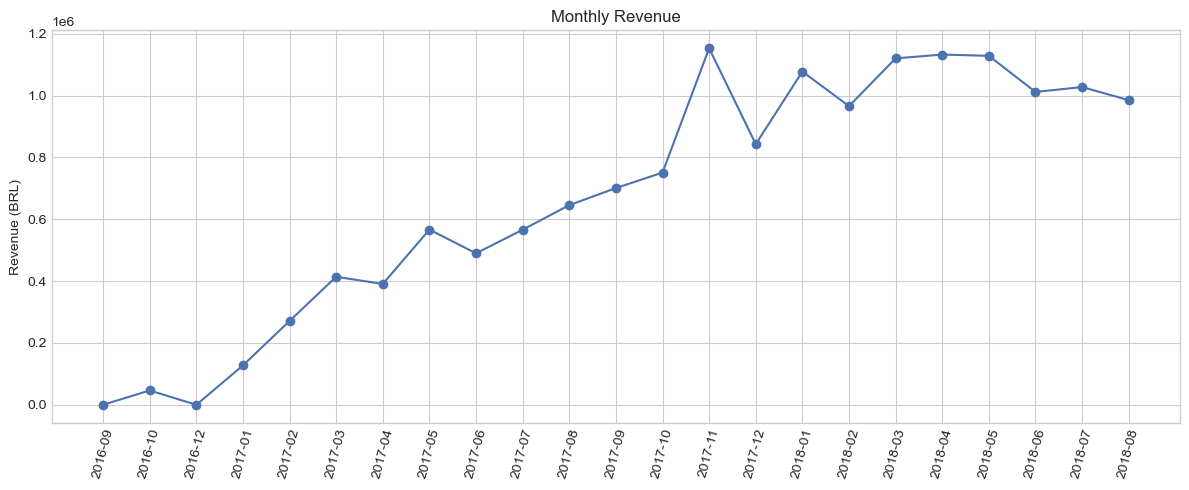

,order_year_month,revenue
0,2016-09,143.46
1,2016-10,46490.66
2,2016-12,19.62
3,2017-01,127482.37
4,2017-02,271239.32


In [15]:
monthly_sales = (    master.groupby("order_year_month")["revenue"]    .sum().reset_index().sort_values("order_year_month"))
plt.figure(figsize=(12,5))
plt.plot(monthly_sales["order_year_month"], monthly_sales["revenue"], marker="o")
plt.xticks(rotation=75)
plt.title("Monthly Revenue")
plt.ylabel("Revenue (BRL)")
plt.tight_layout()
plt.show()
monthly_sales.head()

### Monthly Revenue

This chart shows the monthly revenue trend across the Olist e-commerce business. It helps identify changes in revenue over time, periods of stronger sales performance, and potential seasonal patterns.

The overall trend can be used to understand how the business's revenue evolved throughout the analyzed period and to identify months that require further investigation.

### 6.2 Orders by month

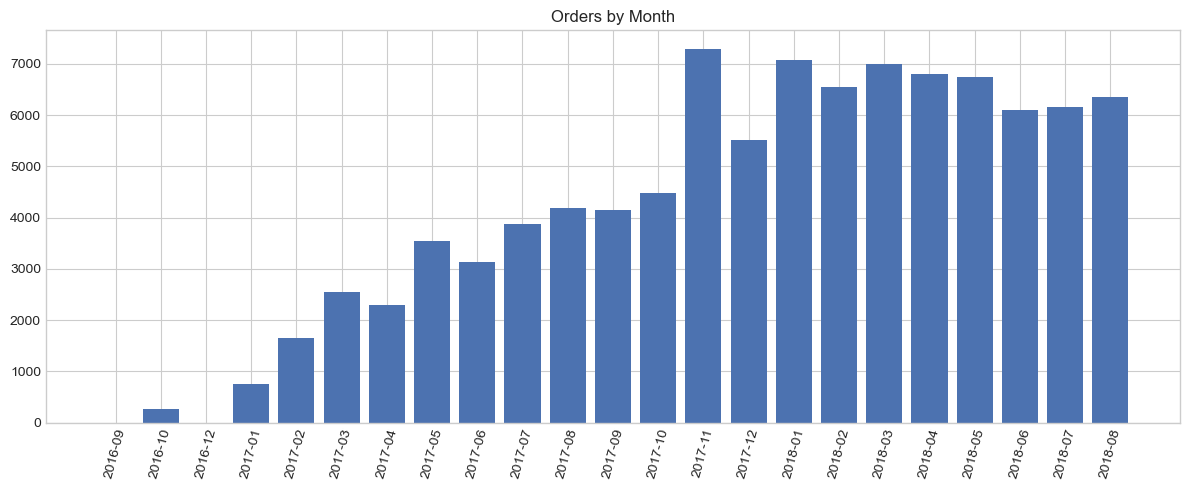

In [16]:
orders_by_month = (    master.groupby("order_year_month")["order_id"]    .nunique().reset_index(name="order_count").sort_values("order_year_month"))
plt.figure(figsize=(12,5))
plt.bar(orders_by_month["order_year_month"], orders_by_month["order_count"])
plt.xticks(rotation=75)
plt.title("Orders by Month")
plt.tight_layout()
plt.show()

### Orders by Month

This chart presents the number of orders placed during each month of the analyzed period. It provides a clear view of changes in customer order activity over time.

The monthly pattern can help identify periods of increasing or decreasing demand and can support decisions related to inventory planning, marketing campaigns, staffing, and logistics capacity.

### 6.3 Top categories by revenue

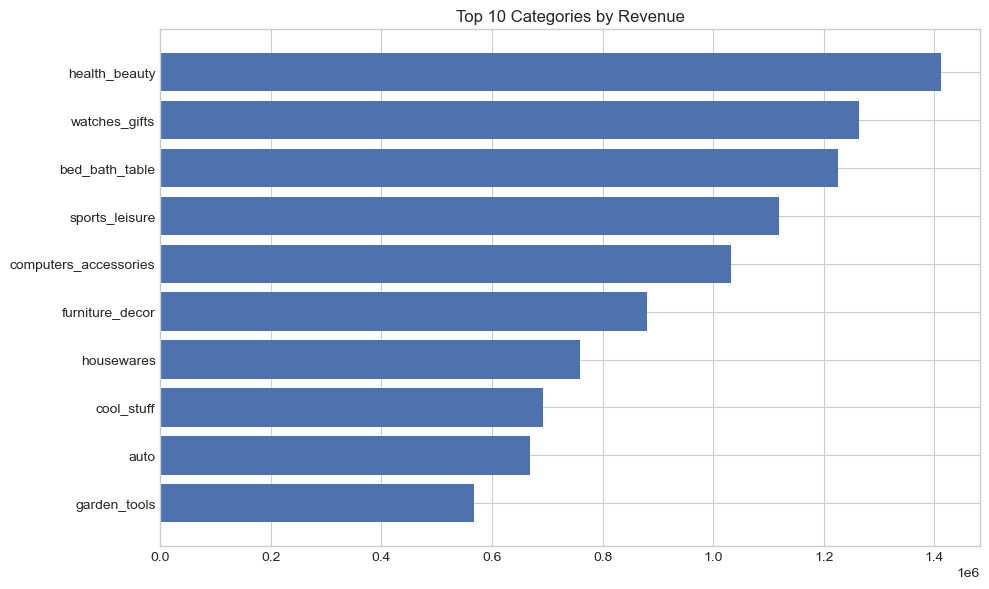

,product_category_name_english,revenue
43,health_beauty,1412089.53
71,watches_gifts,1264333.12
7,bed_bath_table,1225209.26
65,sports_leisure,1118256.91
15,computers_accessories,1032723.77
39,furniture_decor,880329.92
49,housewares,758392.25
20,cool_stuff,691680.89
5,auto,669454.75
42,garden_tools,567145.68


In [17]:
category_sales = (    master.groupby("product_category_name_english")["revenue"]    .sum().reset_index().sort_values("revenue", ascending=False))
top10_categories = category_sales.head(10)
plt.figure(figsize=(10,6))
plt.barh(top10_categories["product_category_name_english"], top10_categories["revenue"])
plt.gca().invert_yaxis()
plt.title("Top 10 Categories by Revenue")
plt.tight_layout()
plt.show()
category_sales.head(10)

### Top 10 Product Categories by Revenue

This chart ranks the top 10 product categories based on revenue generated.

It helps identify the product categories that contribute most significantly to overall sales performance. These insights can support decisions related to inventory management, marketing priorities, category strategy, and revenue growth opportunities.

### 6.4 Top products by revenue

In [18]:
top_products = (    master.groupby("product_id")["revenue"]    .sum().reset_index().sort_values("revenue", ascending=False).head(10))
top_products

,product_id,revenue
23546,bb50f2e236e5eea0100680137654686c,67258.03
26436,d1c427060a0f73f6b889a5c7c61f2ac4,58957.31
13749,6cdd53843498f92890544667809f1595,57933.73
19290,99a4788cb24856965c36a24e339b6058,49907.50
7881,3dd2a17168ec895c781a9191c1e95ad7,47876.06
26997,d6160fb7873f184099d9bc95e30376af,47314.18
21617,aca2eb7d00ea1a7b8ebd4e68314663af,44197.75
12074,5f504b3a1c75b73d6151be81eb05bdc9,41725.81
4892,25c38557cf793876c5abdd5931f922db,40311.95
10616,53b36df67ebb7c41585e8d54d6772e08,39713.49


### 6.5 Orders by customer state

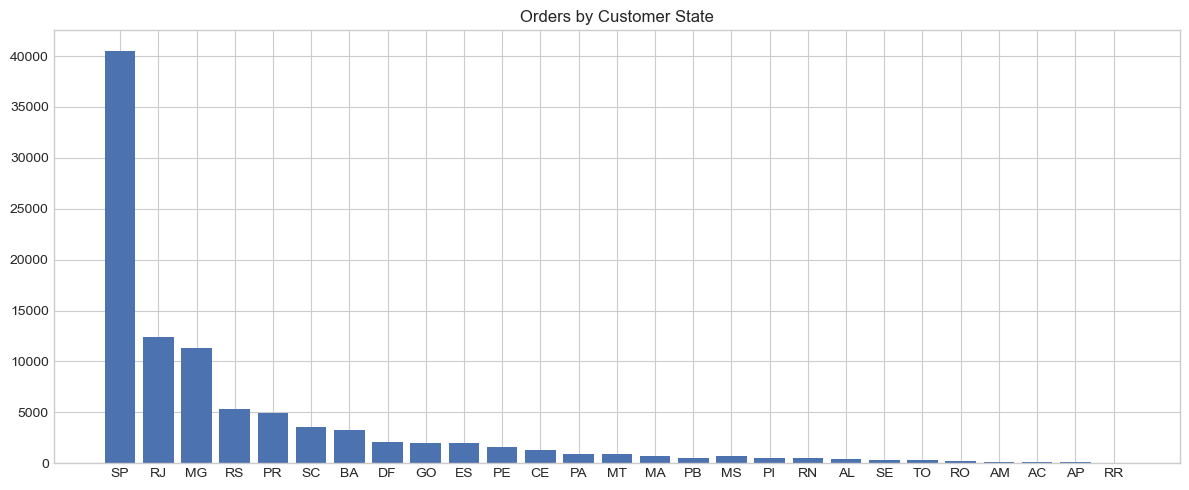

,customer_state,revenue,orders
25,SP,5769703.15,40501
18,RJ,2055401.57,12350
10,MG,1818891.67,11354
22,RS,861472.79,5345
17,PR,781708.80,4923
23,SC,595127.78,3546
4,BA,591137.81,3256
6,DF,346123.35,2080
8,GO,334212.35,1957
7,ES,317657.93,1995


In [19]:
state_sales = (    master.groupby("customer_state")    .agg(revenue=("revenue", "sum"), orders=("order_id", "nunique"))    .reset_index().sort_values("revenue", ascending=False))
plt.figure(figsize=(12,5))
plt.bar(state_sales["customer_state"], state_sales["orders"])
plt.title("Orders by Customer State")
plt.tight_layout()
plt.show()
state_sales.head(10)

### Orders by Customer State

This chart compares the number of orders across Brazilian customer states. It helps identify the geographic regions that contribute the largest share of order volume.

The distribution can be used to understand the concentration of customer demand and identify important regional markets for sales, logistics, and future business expansion.

### 6.6 Payment methods

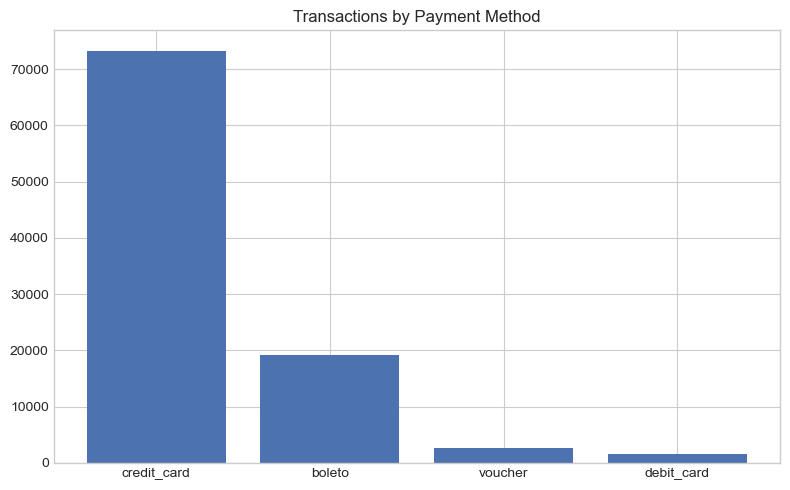

,payment_type,transactions
1,credit_card,73220
0,boleto,19191
3,voucher,2582
2,debit_card,1484


In [20]:
payment_analysis = (    master.groupby("payment_type")["order_id"]    .nunique().reset_index(name="transactions").sort_values("transactions", ascending=False))
plt.figure(figsize=(8,5))
plt.bar(payment_analysis["payment_type"], payment_analysis["transactions"])
plt.title("Transactions by Payment Method")
plt.tight_layout()
plt.show()
payment_analysis

### Payment Method

This chart shows the distribution of orders across the different payment methods used by Olist customers.

It helps identify the most commonly used payment methods and provides insight into customer payment preferences. Understanding payment behavior can support decisions related to payment integration, checkout experience, and customer convenience.


### 6.7 Delivery performance

In [21]:
avg_delivery_days = orders["delivery_days"].mean()
late_pct = orders["is_late"].mean() * 100
delivery_analysis = orders.groupby("order_year_month").agg(    avg_delivery_days=("delivery_days", "mean"),
late_pct=("is_late", "mean")).reset_index()
delivery_analysis["late_pct"] = delivery_analysis["late_pct"] * 100
print(f"Average delivery days: {avg_delivery_days:.2f}")
print(f"Late delivery rate: {late_pct:.2f}%")
delivery_analysis.head()

Average delivery days: 12.09
Late delivery rate: 7.87%


,order_year_month,avg_delivery_days,late_pct
0,2016-09,54.000000,25.000000
1,2016-10,19.111111,0.925926
2,2016-12,4.000000,0.000000
3,2017-01,12.092000,2.875000
4,2017-02,12.606171,2.977528


### 6.8 Review score distribution

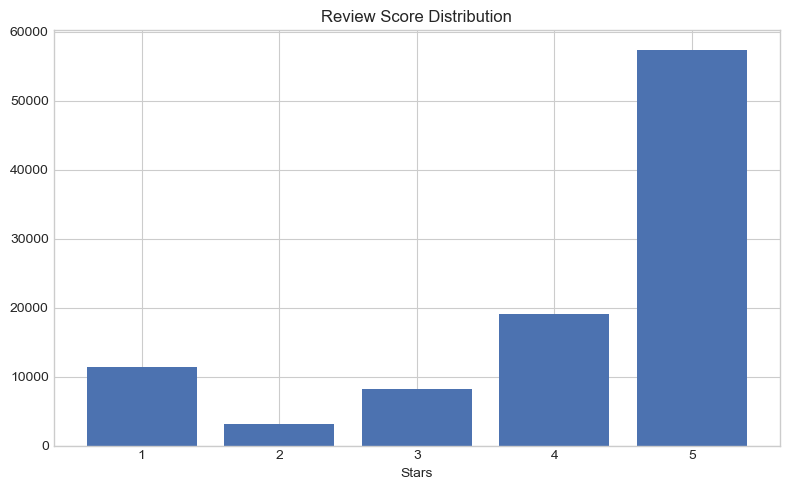

,review_score,count
0,1,11424
1,2,3151
2,3,8179
3,4,19142
4,5,57328


In [22]:
review_analysis = reviews["review_score"].value_counts().sort_index().reset_index()
review_analysis.columns = ["review_score", "count"]
plt.figure(figsize=(8,5))
plt.bar(review_analysis["review_score"].astype(str), 
review_analysis["count"])
plt.title("Review Score Distribution")
plt.xlabel("Stars")
plt.tight_layout()
plt.show()
review_analysis

### Review Score

This chart shows the distribution of customer review scores across the Olist platform.

It provides an overview of customer satisfaction and helps identify how frequently different review ratings occur. The distribution can also be analyzed alongside delivery performance, product categories, and other operational factors to understand potential drivers of customer satisfaction.

## Section 7 — Export Processed OutputsThese CSVs feed Power BI directly and give you a lightweight, versioned dataset for the repo.

In [23]:
import os
os.makedirs("../data/processed", exist_ok=True)
monthly_sales.to_csv("../data/processed/monthly_sales.csv", index=False)
category_sales.to_csv("../data/processed/category_sales.csv", index=False)
state_sales.to_csv("../data/processed/state_sales.csv", index=False)
payment_analysis.to_csv("../data/processed/payment_analysis.csv", index=False)
delivery_analysis.to_csv("../data/processed/delivery_analysis.csv", index=False)
review_analysis.to_csv("../data/processed/review_analysis.csv", index=False)
print("All processed files exported to data/processed/")

All processed files exported to data/processed/


In [24]:
print("Total revenue:", master["revenue"].sum())

print(
    "Average order value:",
    master.groupby("order_id")["revenue"].sum().mean()
)

print("Average delivery days:", orders["delivery_days"].mean())

print(
    "Late delivery rate:",
    orders["is_late"].mean() * 100
)

print(
    "Top category by revenue:",
    category_sales.iloc[0]["product_category_name_english"]
)

print(
    "Top state by orders:",
    state_sales.iloc[0]["customer_state"]
)

print(
    "Most common payment method:",
    payment_analysis.iloc[0]["payment_type"]
)

print("Average review score:", reviews["review_score"].mean())

Total revenue: 15419773.75
Average order value: 159.82683876116832
Average delivery days: 12.094085575687217
Late delivery rate: 7.870998883760219
Top category by revenue: health_beauty
Top state by orders: SP
Most common payment method: credit_card
Average review score: 4.08642062404257


###Section 8 — Key Findings- Total revenue: `15419773.75`- Average order value: `159.82`- Average delivery days: `12.09`- Late delivery rate: `7.87`- Top category by revenue: ` health_beauty`- Top state by orders: `SP`- Most common payment method: `Credit Card`- Average review score: `5`

# 8.Key Findings

## Sales Performance

- Total orders: 99k
- Total revenue: R$ 13.6M
- Average Order Value: R$ 136.6
- Highest revenue month: 2017-11

## Product Performance

- Top category by revenue: Health_Beauty
- Top category by order volume: Health_Beauty
- Top-performing product: Health_Beauty

## Customer Geography

- State with the highest number of orders: SP
- State with the highest revenue: SP

## Delivery Performance

- Average delivery time: 12.5 days
- Late delivery rate: 8.1%

## Payment Behavior

- Most frequently used payment method: Credit_Card

## Customer Satisfaction

- Average review score: 4.09 / 5
- Highest-rated category: Health_Beauty

# 9. Conclusion

This analysis provides an end-to-end view of the Olist e-commerce
business, covering sales, products, customers, payments, delivery
performance, and customer satisfaction.

The analysis was further extended through SQL business questions and an
interactive Power BI dashboard.

The combined workflow demonstrates how raw transactional data can be
transformed into business insights using Python, SQL, data modeling,
DAX, and Power BI.